# The goal 
The goal of this notebook is to try classic PPO on a simple game RugbyHRL designed to be used with variante and understand task scheduling

https://medium.com/@coldstart_coder/ppo-pytorch-implementation-4322372a91d2

In [10]:
#Imports
import sys
import os
sys.path.append(os.path.abspath('..')) 
import numpy as np
import random
import torch
import gymnasium as gym
import src.env

## Config
Here we will choose our env variable   

In [11]:
seed = 444
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
torch.backends.cudnn.deterministic = True

env_name = "RugbyHRLGame1-v0"
num_envs=10
envs = gym.make_vec(env_name, num_envs=num_envs, vectorization_mode="sync")

In [12]:
from tensordict import TensorDict
import torch

class PPORolloutCollector:
    def __init__(self, agent, envs, num_steps_per_rollout, device, eval_env=None):
        self.agent = agent
        self.envs = envs
        self.num_envs = envs.num_envs
        self.num_steps_per_rollout = num_steps_per_rollout
        self.device = device
        self.eval_env = eval_env

        self.obs_shape = envs.single_observation_space.shape
        self.action_shape = envs.single_action_space.shape
        self.initial_buffer_shape = (num_steps_per_rollout, envs.num_envs)

        # go ahead and reset the environment and store the observation
        # and set next_done to false (we assume the environment can't start terminal)
        obs, _ = envs.reset()
        self.next_obs = torch.Tensor(obs).to(device)
        self.next_done = torch.zeros(num_envs).to(device)

    def _create_buffer(self):
        return TensorDict({
            "obs": torch.zeros(self.initial_buffer_shape + self.obs_shape).to(self.device),
            "actions": torch.zeros(self.initial_buffer_shape + self.action_shape).to(self.device),
            "log_probs": torch.zeros(self.initial_buffer_shape).to(self.device),
            "rewards": torch.zeros(self.initial_buffer_shape).to(self.device),
            "dones": torch.zeros(self.initial_buffer_shape).to(self.device),
            "critic_values": torch.zeros(self.initial_buffer_shape).to(self.device),
        })

    # function that will collect num_steps_per_rollout observations against our training environment
    def get_next_rollout(self):
        buffer = self._create_buffer()

        # get the last recorded observation and if that observation is terminal
        next_obs = self.next_obs
        next_done = self.next_done

        # collect the rollouts,
        for t in range(self.num_steps_per_rollout):
            # record the current observation and terminal
            buffer["obs"][t] = next_obs
            buffer["dones"][t] = next_done

            # query the agent for the next action, the log prob of that action, and the critic estimation
            with torch.no_grad():
                action, log_prob, entropy = self.agent.get_actor_values(next_obs)
                critic_value = self.agent.get_critic_value(next_obs)

            # record the values
            buffer["actions"][t] = action
            buffer["log_probs"][t] = log_prob
            buffer["critic_values"][t] = critic_value.flatten()

            # perform the action
            next_obs, reward, terminations, truncations, infos = envs.step(action.cpu().numpy())

            # shape and store the rewards
            reward = torch.tensor(reward).to(self.device).view(-1)
            buffer["rewards"][t] = reward

            # some environments will terminate (meaning the agent is in a final state),
            # others will truncate (ex a time limit is reached but not in a terminal state)
            # these are important distinctions, but for our purposes mean the same thing, the simulation ended.
            # so if either is true and the simulation resets we set next done to true
            next_done = np.logical_or(terminations, truncations)
            # store the next obs and next done for the next round
            next_obs, next_done = torch.Tensor(next_obs).to(self.device), torch.Tensor(next_done).to(self.device)

        # store the next obs and next done in the buffer
        # this is to handle edge cases when calculating advantages later,
        buffer['next_obs'] = next_obs
        buffer['next_done'] = next_done
        # we'll also need the critic estimate for this next state, we'll use this to bootstrap the reward for the final state
        # when we calculate gae
        with torch.no_grad():
            buffer['next_value'] = self.agent.get_critic_value(next_obs).reshape(1, -1)
        self.next_obs = next_obs
        self.next_done = next_done
        return buffer


    # meant for evaluation on the agent on our environment, and will run an entire simulation to termination
    # very similar to the above, the only difference is that we will manually check if the environment terminates
    # and then end the loop,
    # will return a normal python dict with the rewards, entropy, reward averages, average entropy of our agent, and the total rewards for each run
    def run_eval_rollout(self, num_episodes: int = 5):
        assert self.eval_env is not None, "No eval_env provided."

        rewards_per_timestep = []
        entropies_per_timestep = []
        final_rewards = []
        total_entropies = []

        for _ in range(num_episodes):
            obs, _ = self.eval_env.reset()
            obs = torch.tensor(obs, device=self.device).unsqueeze(0)
            done = False

            episode_rewards = []
            episode_entropies = []

            while not done:
                with torch.no_grad():
                    action, _, entropy = self.agent.get_actor_values(obs)
                    action = action.squeeze()
                obs_np, reward, term, trunc, _ = self.eval_env.step(action.cpu().numpy())
                done = term or trunc

                obs = torch.tensor(obs_np, device=self.device).unsqueeze(0)
                episode_rewards.append(float(reward))
                episode_entropies.append(entropy.item())

            rewards_per_timestep.append(episode_rewards)
            entropies_per_timestep.append(episode_entropies)
            final_rewards.append(sum(episode_rewards))
            total_entropies.append(sum(episode_entropies) / len(episode_entropies))

        return {
            "rewards_per_timestep": rewards_per_timestep,
            "average_reward_per_run": sum(final_rewards) / len(final_rewards),
            "average_entropy_per_run": sum(total_entropies) / len(total_entropies),
            "entropies_per_timestep": entropies_per_timestep,
            "final_rewards": final_rewards,
        }

In [13]:
import torch.nn as nn
from torch.distributions.categorical import Categorical

# An initialization helper. In RL problems, it can be helpful to initialize
# the weights of a network orthogonally, meaning the outputs of each layer are as
# decorrelated as possible. This can improve training stability and efficiency by
# helping gradients flow better and avoiding issues with correlated features that
# might arise from naive initialization. Think of this as making sure that the network
# doesn't start with it's wires crossed,
# This function was taken from the CleanRL implementation of PPO.
def layer_init(layer, std=np.sqrt(2), bias_const=0.0):
    torch.nn.init.orthogonal_(layer.weight, std)
    torch.nn.init.constant_(layer.bias, bias_const)
    return layer


class Agent(nn.Module):
    def __init__(self, envs):
        super().__init__()
        # how large will our input array be?
        # note if we were doing something like image observations
        # we would need to rework this, but lunar lander only provides
        # number arrays representing world state
        input_shape = np.array(envs.single_observation_space.shape).prod()

        # how many actions will our agent have?
        action_shape = envs.single_action_space.n

        # create a 3 layer critic, that will predict
        # the total reward our agent will be expected to receive
        # from a given observation
        self.critic = nn.Sequential(
            layer_init(nn.Linear(input_shape, 64)),
            nn.Tanh(),
            layer_init(nn.Linear(64, 64)),
            nn.Tanh(),
            layer_init(nn.Linear(64,1), std=1.0)
        )

        # create a 3 layer actor which will output a probability distribution
        # representing the probability of which action is best to take given
        # an observation
        self.actor = nn.Sequential(
            layer_init(nn.Linear(input_shape, 64)),
            nn.Tanh(),
            layer_init(nn.Linear(64, 64)),
            nn.Tanh(),
            layer_init(nn.Linear(64, action_shape), std=1.0)
        )


    def save(self, path):
        torch.save(self.state_dict(), path)

    def load(self, path):
        self.load_state_dict(torch.load(path))

    def get_critic_value(self, x):
        return self.critic(x)

    def get_actor_values(self, x, action=None):
        logits = self.actor(x)
        probs = Categorical(logits=logits)
        if action is None:
            action = probs.sample()
        return action, probs.log_prob(action), probs.entropy()

In [14]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
agent = Agent(envs).to(device)
print("using device: ", device)

using device:  cpu


In [15]:
import torch.optim as optim
learning_rate = 2.5e-4
optimizer = optim.Adam(agent.parameters(), lr=learning_rate, eps=1e-5)

In [16]:
# our compute_gae function will take in the buffer and 2 hyper parameters, gamma and gae_lambda which control how much future results will impact the advantage and return
# our function will add 2 new values to the buffer,
# 1. 'advantages' which are the gae calculated advantages for each time step, which will be used to help tune our actor part of the agent
# 2. 'returns' which are the adjusted critic values based on the advantage, think of this as using the advantage to nudge the values of the critic closer to the actual rewards.
# returns will be used to train the critic to making better value predictions.
def compute_gae(buffer, gamma=0.99, gae_lambda=0.95):
    next_done = buffer['next_done']
    critic_values = buffer['critic_values']
    rewards = buffer['rewards']
    dones = buffer['dones']
    num_steps_per_rollout = len(rewards)
    last_step_critic_values = buffer['next_value']

    advantages = torch.zeros_like(rewards).to(device)
    last_gae_value = 0
    with torch.no_grad():

        # since gae is forward looking and uses future values, we can be a bit clever and work backwards
        # we'll calculate the last advantage first, then when we calculate the next to last we'll have the recursive
        # future value saved, and so on and so forth,
        for t in reversed(range(num_steps_per_rollout)):
            # check if we're on the last timestep, if we are then use the last_step_critic_values which is the critic prediction
            # for the last state from our environment, the one we haven't actually taken actions against yet. otherwise we look forward
            # in the buffer to get the next value
            if t == num_steps_per_rollout-1:
                next_nonterminal = 1.0 - next_done
                next_values = last_step_critic_values
            else:
                # otherwise we use the values we've stored in the buffer for the next timestep
                next_nonterminal = 1.0 - dones[t+1]
                next_values = critic_values[t+1]

            # calculate the future reward, discounted by gamma,
            # we also zero out the future reward if the state is terminal
            discounted_estimated_future_reward = gamma * next_values * next_nonterminal

            # next we calculate the temporal difference (TD) error for this timestep
            td_error = rewards[t] + discounted_estimated_future_reward - critic_values[t]

            # now we calculate the advantage recursively,
            current_advantage = td_error + gamma * gae_lambda * next_nonterminal * last_gae_value

            # record this advantage
            advantages[t] = current_advantage
            # since we are computing advantages backwards, we can store the current advantage and use it as the future advantage
            # for the next step!
            last_gae_value = current_advantage
    # store our calculated advantages
    buffer['advantages'] = advantages
    # and calculate and store our returns,
    returns = advantages + critic_values
    buffer['returns'] = returns
    return buffer

In [17]:
def run_ppo_update_step(update_epochs_per_rollout, agent, optimizer, buffer, batch_size, minibatch_size,
                      clip_coef=0.2, ent_coef=0.05, vf_coef=0.5,
                      should_normalize_advantages=True, max_grad_norm=0.5):
    # prepare safe shapes for reshape (guard against None typed shapes)
    obs_shape = envs.single_observation_space.shape
    if obs_shape is None:
        obs_shape_tuple = ()
    else:
        obs_shape_tuple = tuple(obs_shape)

    action_shape = envs.single_action_space.shape
    if action_shape is None:
        action_shape_tuple = ()
    else:
        action_shape_tuple = tuple(action_shape)

    # prep the buffers for training
    b_obs = buffer['obs'].reshape((-1,) + obs_shape_tuple)
    b_logprobs = buffer['log_probs'].reshape(-1)
    b_actions = buffer['actions'].reshape((-1,) + action_shape_tuple)
    b_advantages = buffer['advantages'].reshape(-1)
    b_returns = buffer['returns'].reshape(-1)
    b_inds = np.arange(batch_size)

    for epoch in range(update_epochs_per_rollout):
        np.random.shuffle(b_inds)

        for start in range(0, batch_size, minibatch_size):
            end = start + minibatch_size

            mb_inds = b_inds[start:end]

            _, new_log_prob, entropy = agent.get_actor_values(b_obs[mb_inds], action = b_actions[mb_inds])
            new_critic_value = agent.get_critic_value(b_obs[mb_inds])

            log_ratio = new_log_prob - b_logprobs[mb_inds]
            ratio = log_ratio.exp()

            mb_advantages = b_advantages[mb_inds]
            # normalize advantages as part of the mini-batch,
            # normalizing at mini-batch level as opposed to the entire buffer typically helps
            # stabilize training and leads to better results!
            if should_normalize_advantages:
                mb_advantages = (mb_advantages - mb_advantages.mean()) / (mb_advantages.std() + 1e-8)


            # Policy loss
            pg_loss1 = -mb_advantages * ratio
            pg_loss2 = -mb_advantages * torch.clamp(ratio, 1 - clip_coef, 1 + clip_coef)
            pg_loss = torch.max(pg_loss1, pg_loss2).mean()

            # value loss
            new_critic_value = new_critic_value.view(-1)
            v_loss = 0.5 * ((new_critic_value - b_returns[mb_inds]) ** 2).mean()


            entropy_loss = entropy.mean()
            loss = pg_loss - ent_coef * entropy_loss + v_loss * vf_coef

            optimizer.zero_grad()
            loss.backward()
            nn.utils.clip_grad_norm_(agent.parameters(), max_grad_norm)
            optimizer.step()


In [18]:
import time
import os

# define some hyper params
num_training_iterations = 1000 
num_steps_per_rollout = 300  
minibatch_size = 256 
update_epochs_per_rollout = 4

iterations_per_eval = 10 # how often should we do an eval?
runs_per_eval = 5 # how many times should we run the simulation when evaluating?

# define where to save our agent checkpoints and make sure the directory exists
output_model_checkpoints_base = "./checkpoints"
os.makedirs(output_model_checkpoints_base, exist_ok=True)

# A single non-vectorized env used only for evaluation.
# Unlike the training envs (which auto-reset and run in parallel),
# this one runs one full episode at a time so we can measure real performance.
eval_env = gym.make(env_name)

# Init the rollout collector
rollout_collector = PPORolloutCollector(
    agent=agent,
    envs=envs,
    num_steps_per_rollout=num_steps_per_rollout,
    device=device,
    eval_env=eval_env,   # ← now provided
)

# keeping track of how long it will take to run!
elapsed_timesteps = 0
start_time = time.time()

average_eval_reward = []
average_eval_entropy = []

for iteration in range(num_training_iterations):
    agent.train()
    print(f"\rtraining iteration: {iteration}/{num_training_iterations} - runtime: {time.time() - start_time:.2f}", end='', flush=True)

    buffer = rollout_collector.get_next_rollout()
    buffer = compute_gae(buffer)

    run_ppo_update_step(
        update_epochs_per_rollout,
        agent,
        optimizer,
        buffer,
        batch_size=num_envs * num_steps_per_rollout,
        minibatch_size=minibatch_size
    )

    elapsed_timesteps += num_envs * num_steps_per_rollout

    if iteration % iterations_per_eval == 0 or iteration == num_training_iterations - 1:
        with torch.no_grad():
            agent.eval()

            eval_stats = rollout_collector.run_eval_rollout(num_episodes=runs_per_eval)
            avg_reward = eval_stats["average_reward_per_run"]
            avg_entropy = eval_stats['average_entropy_per_run']
            average_eval_reward.append(avg_reward)
            average_eval_entropy.append(avg_entropy)

            ckpt_path = os.path.join(output_model_checkpoints_base, f"checkpoint_{iteration}.pth")
            agent.save(ckpt_path)
            agent.train()

        elapsed = time.time() - start_time
        print(f"\riteration {iteration}/{num_training_iterations} | timesteps: {elapsed_timesteps} | "
                f"avg_eval_reward: {avg_reward:.2f} | avg_eval_entropy: {avg_entropy:.2f} | runtime: {elapsed:.2f}s")

# save out our agent to a final model
final_ckpt_path = os.path.join(output_model_checkpoints_base, "!final_model.pth")
agent.save(final_ckpt_path)
eval_env.close()


iteration 0/1000 | timesteps: 3000 | avg_eval_reward: 2.97 | avg_eval_entropy: 1.71 | runtime: 1.18s
iteration 0/1000 | timesteps: 3000 | avg_eval_reward: 2.97 | avg_eval_entropy: 1.71 | runtime: 1.18s
iteration 10/1000 | timesteps: 33000 | avg_eval_reward: 3.01 | avg_eval_entropy: 1.74 | runtime: 6.71s
iteration 10/1000 | timesteps: 33000 | avg_eval_reward: 3.01 | avg_eval_entropy: 1.74 | runtime: 6.71s
iteration 20/1000 | timesteps: 63000 | avg_eval_reward: 3.00 | avg_eval_entropy: 1.75 | runtime: 12.41s
iteration 20/1000 | timesteps: 63000 | avg_eval_reward: 3.00 | avg_eval_entropy: 1.75 | runtime: 12.41s
iteration 30/1000 | timesteps: 93000 | avg_eval_reward: 3.00 | avg_eval_entropy: 1.75 | runtime: 17.96s
iteration 30/1000 | timesteps: 93000 | avg_eval_reward: 3.00 | avg_eval_entropy: 1.75 | runtime: 17.96s
iteration 40/1000 | timesteps: 123000 | avg_eval_reward: 3.00 | avg_eval_entropy: 1.76 | runtime: 24.51s
iteration 40/1000 | timesteps: 123000 | avg_eval_reward: 3.00 | avg_eva

KeyboardInterrupt: 

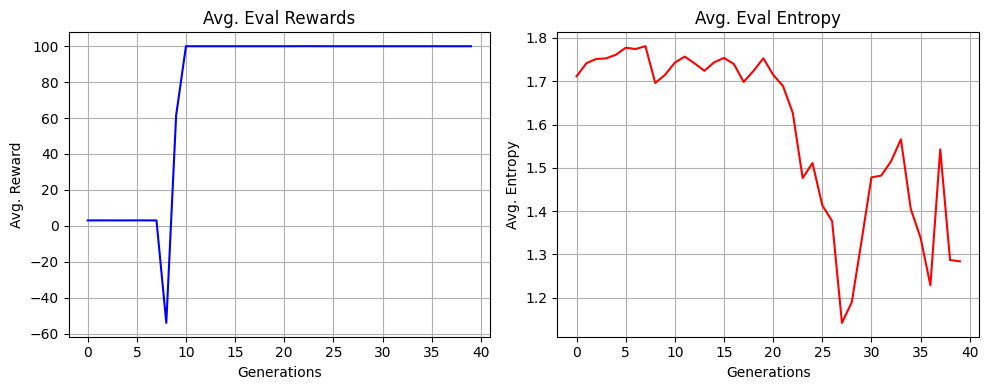

In [19]:
import matplotlib.pyplot as plt
import numpy as np

generations = [i for i in range(len(average_eval_entropy))]

# Create a figure and two subplots arranged in 1 row and 2 columns
fig, (ax1, ax2) = plt.subplots(nrows=1, ncols=2, figsize=(10, 4))

# Plot average rewards on the first subplot (ax1)
ax1.plot(generations, average_eval_reward, label="Avg. Eval Rewards", color="blue")
ax1.set_title('Avg. Eval Rewards')
ax1.set_xlabel('Generations')
ax1.set_ylabel('Avg. Reward')
ax1.grid(True)

# Plot average entropy on the second subplot (ax2)
ax2.plot(generations, average_eval_entropy, label="Avg. Eval Entropy", color="red")
ax2.set_title('Avg. Eval Entropy')
ax2.set_xlabel('Generations')
ax2.set_ylabel('Avg. Entropy')
ax2.grid(True)

# Adjust layout to prevent titles/labels from overlapping
plt.tight_layout()

# Display the plot
plt.show()

## Watch a checkpoint play
Load a saved `.pth` checkpoint and watch the agent play using the pygame renderer.

In [ ]:
import pygame
import gymnasium as gym
import torch

CHECKPOINT_PATH = "./checkpoints/checkpoint_390.pth"  
NUM_EPISODES    = 3                                 
MAX_STEPS       = 2_000                              
FPS             = 30                             

watch_agent = Agent(envs).to(device)
watch_agent.load(CHECKPOINT_PATH)
watch_agent.eval()

watch_env = gym.make(env_name, render_mode="human")

watch_env.reset()
watch_env.render()

clock = pygame.time.Clock()

for episode in range(NUM_EPISODES):
    obs, _ = watch_env.reset()
    obs_t = torch.tensor(obs, dtype=torch.float32, device=device).unsqueeze(0)
    done = False
    total_reward = 0.0
    step = 0

    watch_env.render()

    while not done and step < MAX_STEPS:
        for event in pygame.event.get():
            if event.type == pygame.QUIT:
                done = True
                break

        if done:
            break

        with torch.no_grad():
            action, _, _ = watch_agent.get_actor_values(obs_t)
            action = action.squeeze().item()

        obs, reward, terminated, truncated, info = watch_env.step(action)
        watch_env.render()

        obs_t = torch.tensor(obs, dtype=torch.float32, device=device).unsqueeze(0)
        total_reward += reward
        done = terminated or truncated
        step += 1

        clock.tick(FPS)  # cap the frame rate

    print(f"Episode {episode + 1}/{NUM_EPISODES} — steps: {step}  total reward: {total_reward:.3f}  won: {info.get('won', False)}")

watch_env.close()
print("Done watching.")


Episode 1/3 — steps: 108  total reward: -98.835  won: False
Episode 2/3 — steps: 165  total reward: -93.360  won: False
Episode 3/3 — steps: 1  total reward: -100.000  won: False
Done watching.
Episode 2/3 — steps: 165  total reward: -93.360  won: False
Episode 3/3 — steps: 1  total reward: -100.000  won: False
Done watching.
